In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import time
import tracemalloc
from minisom import MiniSom
import somJ.config as config
from somJ.functions import *
from somJ.som import SoM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import gc
import warnings
from sklearn.model_selection import StratifiedKFold
from scipy.stats import mode
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [3]:
X, y = load_dataset("MNIST")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
som = SoM(
    method="pca",
    data=X_train,
    total_nodes=config.TOTAL_NODES
)
t0 = time.time()
som.train(
    train_data=X_train,
    learn_rate=config.LEARNING_RATE,
    sigma=1,
    epochs=1,
)
X_train_scaled=som.scaler.transform(X_train)
X_test_scaled=som.scaler.transform(X_test)
X_train_emb = np.array([som.find_winner(x) for x in X_train_scaled])
X_test_emb  = np.array([som.find_winner(x) for x in X_test_scaled])

In [ ]:
label_map = {}
for coord, label in zip(X_train_emb[:200], y_train[:200]):
    coord = tuple(coord)
    label_map.setdefault(coord, []).append(label)
neuron_labels = {coord: max(labels, key=labels.count)
                for coord, labels in label_map.items()}

# Predecir para test
y_pred = []
for coord in X_test_emb:
    coord = tuple(coord)
    if coord in neuron_labels:
        y_pred.append(neuron_labels[coord])
    else:
        # buscar neurona etiquetada más cercana
        dists = [ (coord[0]-c[0])**2 + (coord[1]-c[1])**2
                for c in neuron_labels.keys() ]
        nearest = list(neuron_labels.keys())[np.argmin(dists)]
        y_pred.append(neuron_labels[nearest])
y_pred = np.array(y_pred)

In [12]:
max_row,max_col=som.grid_size
matrix = np.full((max_row, max_col), -1)

# Llenamos la matriz con los valores del diccionario
for (i, j), value in neuron_labels.items():
    matrix[i, j] = value

print(matrix)

[[ 9  9  4 -1  7  7  7 -1  7]
 [ 4  9  4  4  6  7  7  9  7]
 [ 9  9  4  4  4 -1  2  2  2]
 [ 4  9  9  4  7  2  2 -1  2]
 [ 4  9  8  3  3  6  6  2  2]
 [ 1  8  8  3  5  6  6  6  6]
 [ 1  8  8  8  5  5  6  6 -1]
 [ 1  1  8  8  5  8  6 -1 -1]
 [ 1  7  3  3  5  5  0  0  0]
 [ 1  2  8  3 -1  3  0  0  0]
 [ 1  1  3  5  8  3  3  0  0]]


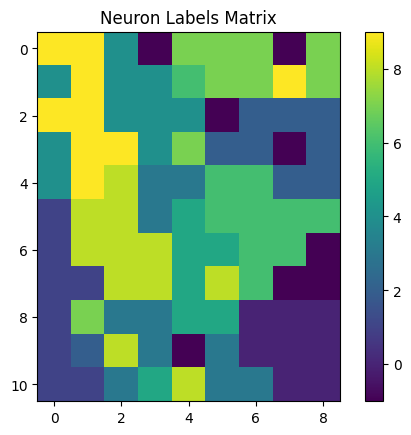

In [13]:
plt.imshow(matrix, cmap='viridis', interpolation='none')
plt.colorbar()
plt.title('Neuron Labels Matrix')
plt.show()

In [ ]:
def fill_labels(neuron_labels, shape, missing_value=-1, max_iter=10):
    # Crear matriz con valor por defecto
    matrix = np.full(shape, missing_value)
    for (i, j), value in neuron_labels.items():
        matrix[i, j] = value

    def fill_with_neighbor_mode(matrix, missing_value=-1):
        filled = matrix.copy()
        rows, cols = filled.shape

        for i in range(rows):
            for j in range(cols):
                if filled[i, j] == missing_value:
                    neighbors = []
                    for dx in [-1, 0, 1]:
                        for dy in [-1, 0, 1]:
                            if dx == 0 and dy == 0:
                                continue
                            ni, nj = i + dx, j + dy
                            if 0 <= ni < rows and 0 <= nj < cols and filled[ni, nj] != missing_value:
                                neighbors.append(filled[ni, nj])
                    if neighbors:
                        counts = np.bincount(np.array(neighbors, dtype=int))
                        most_common = np.argmax(counts)
                        filled[i, j] = most_common
        return filled

    # Iterar hasta rellenar todos los huecos o max_iter
    filled = matrix.copy()
    for _ in range(max_iter):
        prev = filled.copy()
        filled = fill_with_neighbor_mode(filled, missing_value=missing_value)
        if np.array_equal(prev, filled):
            break

    # Convertir matriz resultante a diccionario con todas las coordenadas
    new_labels = {(i, j): int(filled[i, j]) for i in range(shape[0]) for j in range(shape[1])}
    return new_labels


In [ ]:
matriz_rellena = fill_labels(neuron_labels,som.grid_size)
for (i, j), value in matriz_rellena.items():
    matrix[i, j] = value

print(matrix)

[[9 9 4 4 7 7 7 7 7]
 [4 9 4 4 6 7 7 9 7]
 [9 9 4 4 4 2 2 2 2]
 [4 9 9 4 7 2 2 2 2]
 [4 9 8 3 3 6 6 2 2]
 [1 8 8 3 5 6 6 6 6]
 [1 8 8 8 5 5 6 6 6]
 [1 1 8 8 5 8 6 6 6]
 [1 7 3 3 5 5 0 0 0]
 [1 2 8 3 3 3 0 0 0]
 [1 1 3 5 8 3 3 0 0]]


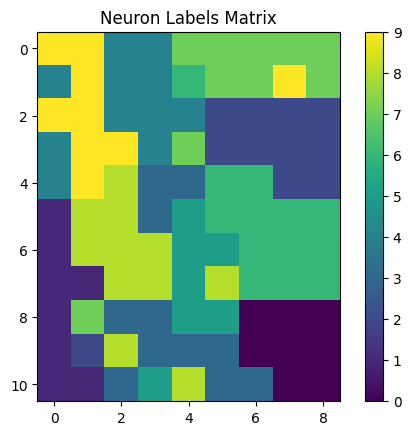

In [22]:
plt.imshow(matriz_rellena, cmap='viridis', interpolation='none')
plt.colorbar()
plt.title('Neuron Labels Matrix')
plt.show()

In [6]:
acc  = accuracy_score(y_test, y_pred)
acc

0.8425